In [1]:
import numpy as np
import pandas as pd
import math
import astropy.constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units as u
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline

In [2]:
#inputs we set
h_agn = 0.017 * const.pc.cgs.value #height of the AGN in cm
dense_agn = 1e-16 #density of the AGN in cgs units
c = const.c.cgs.value #speed of light in cm/s
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = z_at_value(cosmo.luminosity_distance, 410 * u.Mpc)
print(z)
dist = 410 * 1e6 * const.pc.cgs.value #distance to the AGN in cm (410 Megaparsecs)
jet_angle = 0.05 # about 3 degrees in radians (set by paper)
v_fs = 0.6 * c #velocity of forward shock in cm/s breaks if < 0.7 c
#freq = 1e17 #frequency to test in Hz
freq_list = np.logspace(10, 25, 50000) #frequency range to test in Hz log space does 10^ before for the exponents
sound_speed = 5e6 #sound speed 50 km/s in cm/s
p = 2.5 #top right page 8, the power law index of the electron distribution
pa = np.sin(np.pi/2) #pitch angle set to 90 degrees
e = const.e.esu.value #elementary charge in esu (csg)
m_p = const.m_p.cgs.value #proton mass in cgs
m_e = const.m_e.cgs.value

0.08969458230111924 redshift


In [3]:
#beta fs 
b_fs = v_fs / c #page 2 bottom right
b_fs

np.float64(0.6)

In [4]:
e_e = 0.3 #page 8 top right
e_b = 0.1 #page 8 top right
xi = 1 #page 7 top left

def find_b_fs():
    b_fsv = v_fs / c
    return b_fsv

def find_l_sh(jet_angle, h_agn, dense_agn, b_fs):
    l_sh = 5e43 * (jet_angle/0.05)**2 * (h_agn/5.245651888535325e+16)**2 * (dense_agn/1e-16) * (b_fs/0.1)**3 #eq 5
    return l_sh

def find_B_sf(a_gamma_sf, dense_agn):
    print("A_gamma_sf ", a_gamma_sf)
    B_sf = 600 * ((a_gamma_sf/1.5)**(0.5)) * ((e_b/0.1)**(0.5)) * ((dense_agn/1e-16)**(0.5))
    return B_sf

def solve_gamma_a(gamma_m, gamma_max, gamma_sf, B_sf, dense_sf, case):
    gamma_a = gamma_m  # set equal to gamma_m for start guess

    #having the final values set to be an option to print
    final_tq = None
    final_cq = None
    final_tc = None

    for _ in range(100):  #looping it to find gamma a
        if case == 1:
            gamma_1 = gamma_a #when gamma m is larger than gamma a
            gamma_2 = gamma_m
            q = 2
        else:
            gamma_1 = gamma_m #when gamma a is larger than gamma m
            gamma_2 = gamma_max
            q = p #2.5

        #eq 20 (cooling timescale)
        tc_ga = 30 * ((e_b/0.1)**-1) * ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dense_agn/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a/60)**-1)

        delta_shell = tc_ga * v_fs

        #eq 20 (synchotron self absorption)
        ratio = gamma_2 / gamma_1

        if ratio <= 0: #case where gamma 2 is negatice or or it wont be possible
            return np.nan

        denom = 1 - (ratio ** (-q+1))
        
        
         # if gamma2/gamma1 to the power of (-q+1) is 1 the denom is negative and breaks
        if abs(denom) < 1e-10:
            denom = 1e-10

        # eq 22 (synchotron self absorption)
        tq = (np.pi/(3*np.sqrt(3))) * (((q**2 + q - 2)*(gamma_1**-5))/(denom)) * ((e * dense_sf * delta_shell)/(B_sf * pa * m_p))

        #eq 23 (modified to be Cq+1)
        cq_1 = ((2**(((q+2)/2)))/(q+2)) * math.gamma(((q+1)/4)-(1/12)) * math.gamma(((q+1)/4)+(19/12))
        # we need to clarify this with Hiromichi -- running q+1 and q (no modifications) will push the curve over in freq space
        #cq_1 = ((2**(((q+1)/1)))/(q+2)) * math.gamma(((q)/4)-(1/12)) * math.gamma(((q)/4)+(19/12))
        #storing the values used to get final gamma_a

        if np.isfinite(tq) and np.isfinite(cq_1) and np.isfinite(tc_ga): #this only picks real numbers when the eq doesnt break
            final_tq = tq
            final_cq = cq_1
            final_tc = tc_ga

        #eq 21 
        gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))

        if abs(gamma_new - gamma_a)/gamma_a < 1e-3:
            return gamma_new, final_tq, final_cq, final_tc
        gamma_a = gamma_new
    return gamma_a, final_tq, final_cq, final_tc

def find_gammas_tq_cq_tc(b_fs, dense_agn):
    #gamma equations
    gamma_fs = 1/(np.sqrt(1 - b_fs**2)) 

    if b_fs < 0.7:
        gamma_sf = (7/6) * gamma_fs #from hiromichi
        print(f"7/6 gamma_fs = gamma_sf = {gamma_sf}")
    else:
        gamma_sf = gamma_fs / (np.sqrt(2)) #page 5 top left
        
    dense_sf = dense_agn * (((gamma_sf)+1)/((gamma_sf)-1)) # CHANGED 5/3 to gamma_sf density of shock fluid (eq 34 from emilys notes)

    #beta_sf = v_sf / c#b_fs + c1 * (1+ ((gamma_sf)+1)/(2 * (gamma_sf)) * ((p2/p1)-1))**0.5
    v_sf = c * np.sqrt(1 - (1 / gamma_sf**2))

    beta_sf = v_sf/c
    #beta_sf eq CHANGED 5/3 to gamma_sf
    a_gamma_sf = (gamma_sf-1) * ((4*gamma_sf)+3) #left of eq 2

    gamma_sf_f = gamma_sf**(1 + np.sqrt(3)) #page 5 top left
    gamma_m = e_e * ((p-2) / (p-1)) * (m_p/m_e) * (gamma_sf - 1) + 1 # eqn 7 of fab + p 2008 adds +1!! ASK HIROMICHI # 40 * (e_e/0.3) * ((gamma_sf-1)/0.2) #eq 16
    gamma_max = 1e6 * (xi**(-0.5)) * (beta_sf/0.5) * ((a_gamma_sf/1.5)**(-0.25)) * ((e_b/0.1)**(-0.25)) * ((dense_agn/1e-16)**(-0.25)) #eq 17

    B_sf = find_B_sf(a_gamma_sf, dense_agn) # need her for gamma_a solvingggg

    gamma_a_small, tq_small, cq_small, tc_small = solve_gamma_a(gamma_m, gamma_max, gamma_sf, B_sf, dense_sf, case=1)
    gamma_a_big, tq_big, cq_big, tc_big = solve_gamma_a(gamma_m, gamma_max, gamma_sf, B_sf, dense_sf, case=2)

    if gamma_a_small < gamma_m:
        gamma_a = gamma_a_small
        tq_final = tq_small
        cq_final = cq_small
        tc_final = tc_small

    else:
        gamma_a = gamma_a_big
        tq_final = tq_big
        cq_final = cq_big
        tc_final = tc_big

    print(f"gamma_fs: {gamma_fs}")
    print(f"gamma_a_small: {gamma_a_small}")
    print(f"gamma_sf: {gamma_sf}")
    print(f"A_gamma_sf: {a_gamma_sf}" )
    print(f"gamma_m: {gamma_m}")
    print(f"gamma_max: {gamma_max}" )
    print(f"gamma_a: {gamma_a}" )
    print(tq_small, cq_small, tc_small)
    print(tq_big, cq_big, tc_big)
    print(f"Final tq: {tq_final}")
    print(f"Final cq_1: {cq_final}")
    print(f"Final tc: {tc_final}")

    return gamma_fs, gamma_sf, a_gamma_sf, gamma_a, gamma_sf_f, gamma_m, gamma_max, B_sf, tq_final, cq_final, tc_final

def find_l_syn(b_fs, gamma_fs, gamma_sf_f, l_sh):
    #L_syn variable
    f_dilution = 1 #page 6 left of eq 16
    Yssc = (e_e / e_b)**(1/3) #page 8 top left
    Y2ndIC = (e_e / e_b)**(2/3) #page 8 top left
    #page 6 under eq 15
    if b_fs * gamma_fs <= 1: 
        f_beaming = 1
    elif b_fs * gamma_fs > 1:
        f_beaming = 2 * (gamma_sf_f**2)
    l_syn = e_e * f_beaming * f_dilution * (l_sh/(1 + Yssc + Y2ndIC)) # (eq 15)
    return l_syn

In [5]:
gamma_fs, gamma_sf, a_gamma_sf, gamma_a, gamma_sf_f, gamma_m, gamma_max, B_sf, tq_final, cq_final, tc_final = find_gammas_tq_cq_tc(b_fs, dense_agn)
l_sh = find_l_sh(jet_angle, h_agn, dense_agn, b_fs)
l_syn = find_l_syn(b_fs, gamma_fs, gamma_sf_f, l_sh)
print(l_sh)
print(l_syn)

7/6 gamma_fs = gamma_sf = 1.4583333333333335
A_gamma_sf  4.0486111111111125
gamma_fs: 1.25
gamma_a_small: nan
gamma_sf: 1.4583333333333335
A_gamma_sf: 4.0486111111111125
gamma_m: 85.15699753266674
gamma_max: 1135744.386113631
gamma_a: 52.46341123915338
-2.7884084584491925e-12 1.6122661015415265 0.2772405042392587
0.026783414062704358 1.602393838648818 10.456579749201236
Final tq: 0.026783414062704358
Final cq_1: 1.602393838648818
Final tc: 10.456579749201236
1.0799999999999997e+46
7.164443038980013e+44


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_75293/1982792989.py:69: RuntimeWarning: invalid value encountered in scalar power
  gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))


In [6]:

def compute_flux_spectrum(
    freq_list: np.ndarray,
    dist: float,
    l_syn: float,
    gamma_sf: float,
    B_sf: float,
    gamma_m: float,
    gamma_max: float,
    gamma_a: float,
    p: float):

    #freq_sync = 2e9  * (gamma_sf / 1.2)    * (B_sf / 600)
    #freq_m    = 3e12 * (gamma_m  / 40)**2  * (freq_sync / 2e9)
    #freq_max  = 2e21 * (gamma_max / 1e6)**2 * (freq_sync / 2e9)
    #freq_a    = 7e12 * (gamma_a  / 60)**2  * (freq_sync / 2e9)
    gamma_a = 59
    gamma_m = 35
    freq_sync = 2e9 
    freq_m    = 3e12 
    freq_max  = 2e21 
    freq_a    = 7e12
    A_gamma_fs = (gamma_fs - 1) * (4 * gamma_fs + 3)
    e_fs = A_gamma_fs * dense_agn * c**2
    B_fs = (8 * np.pi * e_b * e_fs)**(1/2)
    t_break = (0.3 * u.yr).to('s').value
    factor = (6 * np.pi * const.m_e.cgs.value * c) / (const.sigma_T.cgs.value * B_sf**2 * gamma_sf * t_break)
    gamma_c = max(1, factor)
    freq_c =  ((gamma_fs * gamma_c**2) / (1 + z)) * (e * B_fs)
    freq_a_ssc = (4/3) * gamma_a**2 * freq_a
    freq_m_ssc = (4/3) * gamma_m**2 * freq_m

    freq_a_2sc = (4/3) * gamma_a**2 * freq_a_ssc # i should check if this should be gamma_a or a dif gamma
    freq_m_2sc = (4/3) * gamma_m**2 * freq_m_ssc

    print(f"nu_sync  = {freq_sync:.3e} Hz")
    print(f"nu_a  = {freq_a:.3e} Hz")
    print(f"nu_a_ssc  = {freq_a_ssc:.3e} Hz")
    print(f"nu_a_2sc  = {freq_a_2sc:.3e} Hz")
    print(f"nu_c  = {freq_c:.3e} Hz")
    print(f"nu_m  = {freq_m:.3e} Hz")
    print(f"nu_m_ssc  = {freq_m_ssc:.3e} Hz")
    print(f"nu_m_2sc  = {freq_m_2sc:.3e} Hz")
    print(f"nu_max= {freq_max:.3e} Hz")
    print(f"Regime: {'FAST' if freq_c < freq_m else 'SLOW'} cooling, "
          f"nu_a {'<' if freq_a < min(freq_c, freq_m) else '>'} min(nu_c, nu_m)")

    f = np.asarray(freq_list, dtype=float)

    sa = np.zeros(len(f))
    ssc = np.zeros(len(f))
    o2_ic = np.zeros(len(f))
    o2_ic2 = np.zeros(len(f))

    if freq_a < freq_m:                          
        print("va < vm")
        print("fahh")
        chosen = np.select(
            condlist=[
                (f > freq_m)  & (f < freq_max),
                (f > freq_a)  & (f < freq_m),
                (f > freq_sync) & (f < freq_a),
            ],
            choicelist=[
                (f / freq_m) ** (-(p + 1) / 2),
                (f / freq_m) ** (1 / 2),
                (f / freq_a) ** 3 * (freq_a / freq_m) ** (1 / 2),
            ],
            default=0.0,
        )

        sa = chosen

    if freq_m < freq_a:                                       
        print("vm < va")
        chosen = np.select(
            condlist=[
                (f > freq_a) & (f < freq_max),
                f < freq_a,
            ],
            choicelist=[
                (f / freq_m) ** ((-p+2) / 2) + np.exp(1 - (f / freq_a) ** (1 / 2)),
                (f / freq_a) ** 3,
            ],
            default=0.0,
        )
        ssc = chosen

    if freq_c < freq_m and freq_m < freq_a:        
        print("v_c < v_m < v_a")
        
        chosen = np.select(
            condlist=[
                (f > freq_a_ssc),
                f < freq_a_ssc,
            ],
            choicelist=[
                np.exp(1 - (f / freq_a_ssc)**(1/2)) + (f / freq_m_ssc)**((2-p)/2),
                (f / freq_a_ssc) ** 2,
            ],
            default=0.0,
        )
        Yssc = (e_e / e_b)**(1/3)
        o2_ic = Yssc * chosen

    if freq_c < freq_m and freq_m < freq_a:        
        print("2nd order inv. C. scattering")
        chosen2 = np.select(
            condlist=[
                (f > freq_a_2sc),
                f < freq_a_2sc,
            ],
            choicelist=[
                np.exp(1 - (f / freq_a_2sc)**(1/2)) + (f / freq_m_2sc)**((2-p)/2),
                (f / freq_a_2sc) ** 2,
            ],
            default=0.0,
        )
        Y2sc = (e_e / e_b)**(2/3)
        o2_ic2 = Y2sc * chosen2
    total = sa + ssc + o2_ic + o2_ic2
    luminosity = l_syn * total
    flux = luminosity / (4 * np.pi * dist**2)

    return pd.DataFrame({"freq": f, "luminosity": luminosity, "flux": flux})

df = compute_flux_spectrum(freq_list=freq_list, dist=dist, l_syn=l_syn, gamma_sf=gamma_sf, B_sf=B_sf, gamma_m=gamma_m, gamma_max=gamma_max, gamma_a=gamma_a, p=p)

nu_sync  = 2.000e+09 Hz
nu_a  = 7.000e+12 Hz
nu_a_ssc  = 3.249e+16 Hz
nu_a_2sc  = 1.508e+20 Hz
nu_c  = 3.703e-07 Hz
nu_m  = 3.000e+12 Hz
nu_m_ssc  = 4.900e+15 Hz
nu_m_2sc  = 8.003e+18 Hz
nu_max= 2.000e+21 Hz
Regime: FAST cooling, nu_a > min(nu_c, nu_m)
vm < va
v_c < v_m < v_a
2nd order inv. C. scattering


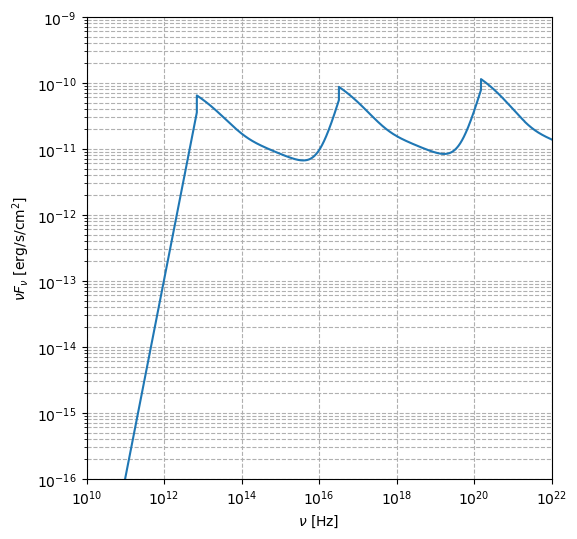

In [7]:
plt.figure(figsize=(6,6))
plt.plot(df['freq'], df['flux'])
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e10,1e22)
plt.ylim(1e-16, 1e-9)
plt.xlabel(r"$\nu$ [Hz]")
plt.ylabel(r"$\nu F_{\nu}$ [erg/s/cm$^2$]")

plt.grid(True, which="both", linestyle="--")
plt.show()